# **Notebook 4: Association Rules and Targeted Promotions**

> **Objective:** Transform raw customer and basket datasets into clean datasets prepared for the next modelling stages. The **customer dataset** is cleaned and feature-engineered for **clustering**, while the **basket dataset** is preserved at transaction level for the generation of **association rules**.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Customer Data Cleaning Pipeline](#3-customer-pipeline)
4. [Basket Data Preparation for Association Rules](#4-basket-association-rules)
5. [Validation Checks](#5-validation)
6. [Export Processed Data](#6-export)

---

## **1. Imports and Data Loading**

In [ ]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
from association import generate_rules

pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)

In [2]:
basket_transaction_df = pd.read_pickle('../data/customer_basket_transactions.pkl')

basket_transaction_df.head()

,invoice_id,list_of_goods,customer_id,basket_size
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8


In [3]:
customer_clusters = pd.read_csv('../data/customer_final_clusters.csv')

customer_clusters.head()

,customer_id,cluster_kmeans,cluster_name
0,3,4,Promotion Lovers
1,4,2,Clean & Green
2,5,0,Regular Cutomers
3,7,1,Gamers
4,8,1,Gamers


## **2. Merging Customer Clusters with Basket Data**

The basket transaction data was merged with the final customer cluster assignment using `customer_id` as the key and using an inner join, keeping only customers assinged to a cluster. The resulting dataset contains 100,000 transactions, meaning that no baskets were lost during the merge.

In [4]:
basket_with_clusters = pd.merge(basket_transaction_df, customer_clusters, on='customer_id', how='inner')

print(basket_with_clusters.shape)
basket_with_clusters.head()

(100000, 6)


,invoice_id,list_of_goods,customer_id,basket_size,cluster_kmeans,cluster_name
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11,3,Senior Karens
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12,4,Promotion Lovers
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7,3,Senior Karens
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4,7,Large Families
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8,7,Large Families


In [5]:
print(basket_with_clusters["cluster_kmeans"].isna().sum())
print(basket_with_clusters["cluster_name"].isna().sum())

0
0


We also checked for missing values in both the cluster ID and cluster name columns, and both returned 0. This confirms that every basket is correctly associated with a customer segment before generating the association rules.

In [6]:
basket_with_clusters["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    20163
1     8260
2    16683
3     3999
4    13635
5    13474
6     8681
7     9079
8     6026
Name: count, dtype: int64

The distribution of baskets by cluster confirms that all 9 customer segments are represented in the transaction data. The largest segment is Cluster 0, with 20,163 baskets, while the smallest segment is Cluster 3, with 3,999 baskets.

We also checked the distribution by `cluster_name` and confirmed that each cluster ID matches the expected segment name. This ensures that the cluster labels are consistent before moving to the cluster-specific association rule analysis.

In [7]:
basket_with_clusters["cluster_name"].value_counts()

cluster_name
Regular Cutomers                  20163
Clean & Green                     16683
Promotion Lovers                  13635
Low-Value Occasional Customers    13474
Large Families                     9079
High-Value Customers               8681
Gamers                             8260
Young Karens                       6026
Senior Karens                      3999
Name: count, dtype: int64

**Everythings looks consistent!**


## **3. Train-Test Split by Customer**

The dataset is split by customer rather than by individual transaction. This allows us to generate association rules on the training set and then evaluate whether the same rules remain stable in a separate holdout set.

In [8]:
customers = basket_with_clusters[['customer_id', 'cluster_kmeans']].drop_duplicates()


train_customers, test_customers = train_test_split(customers, test_size=0.20, random_state=42, stratify=customers['cluster_kmeans'])

In [9]:
train_baskets_df = basket_with_clusters[basket_with_clusters['customer_id'].isin(train_customers['customer_id'])].copy()

test_baskets_df = basket_with_clusters[basket_with_clusters['customer_id'].isin(test_customers['customer_id'])].copy()

**This way, the same customer does not appear in both train and test set. This avoids leakage between both sets and provides a cleaner validation of the association rules.**

In [10]:
train_baskets = list(train_baskets_df['list_of_goods'])
test_baskets = list(test_baskets_df['list_of_goods'])

In [11]:
print('We have {} rows in the train set.'.format(len(train_baskets)))
print('We have {} rows in the test set.'.format(len(test_baskets)))

We have 79847 rows in the train set.
We have 20153 rows in the test set.


In [12]:
overlap = set(train_baskets_df["customer_id"]) & set(test_baskets_df["customer_id"])

print("Customer overlap:", len(overlap))

Customer overlap: 0


No customers overlap.

## **4. Global Association Rules**

In this section, we mine association rules using the full training basket dataset, without separating customers by cluster. These global rules provide a baseline view of the most common product associations across the entire customer base.

The goal is to identify general purchasing patterns before moving to cluster-specific association rules, which will later support targeted promotion strategies for each customer segment.

**Note**: Before any association rules we first encode our data.

### **4.1. Transaction Encoding**

In [13]:
te = TransactionEncoder()
te_fit = te.fit(train_baskets).transform(train_baskets)
transactions_items_train = pd.DataFrame(te_fit, columns = te.columns_)

transactions_items_train.head()

,airpods,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,beer,black beer,black tea,blueberries,bluetooth headphones,body spray,bramble,brownies,burger sauce,burgers,butter,cake,candy bars,canned_tuna,carrots,cat food,catfish,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,cologne,cookies,cooking oil,corn,cottage cheese,cotton buds,cream,deodorant,dessert wine,dog food,eggplant,eggs,energy bar,energy drink,escalope,extra dark chocolate,...,pokemon scarlet,pokemon shield,pokemon sword,pokemon violet,portal,portal 2,protein bar,ratchet & clank,ratchet & clank 2,ratchet & clank 3,razor,red wine,rice,ring light,salad,salmon,salt,samsung galaxy 10,sandwich,seabass,shallot,shampoo,shower gel,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,toilet paper,tomato juice,tomato sauce,tomatoes,tooth brush,toothpaste,trout,turkey,vacuum cleaner,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,Fa

### **4.2. Frequent Itemsets with Apriori algorithm**

Support measures how frequently an itemset appears in the transaction dataset.

In association rules, support is used to filter out very rare itemsets. A higher support means the itemset occurs more often and is therefore based on more evidence. In our case, we use a minimum support threshold of `0.02`, meaning that only itemsets appearing in at least **2% of the training baskets** are kept.

In [14]:
support_itemsets_train = apriori(transactions_items_train, min_support = 0.02, use_colnames=True)

support_itemsets_train.sort_values(by='support', ascending=False).head(15)

,support,itemsets
3,0.128082,(asparagus)
0,0.121708,(airpods)
56,0.100192,(fresh bread)
26,0.099991,(cereals)
18,0.096960,(butter)
45,0.092327,(eggs)
120,0.086240,(protein bar)
36,0.086165,(cooking oil)
5,0.083961,(babies food)
146,0.083560,(toilet paper)


As the item `aspargus` has a support of `0.128`, it means that it appears in approximately 12.8% of the training baskets.

### **4.3. Association Rules**

In [15]:
rules_train = association_rules(support_itemsets_train, metric='confidence', min_threshold = 0.15)

rules_train.sort_values('lift', ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(bluetooth headphones),(airpods),0.072927,0.121708,0.024672,0.338314,2.779721,1.0,0.015796,1.327354,0.690616,0.145162,0.246622,0.270515
1,(airpods),(bluetooth headphones),0.121708,0.072927,0.024672,0.202717,2.779721,1.0,0.015796,1.162790,0.728973,0.145162,0.139999,0.270515
2,(energy drink),(airpods),0.075194,0.121708,0.025060,0.333278,2.738345,1.0,0.015909,1.317329,0.686431,0.145835,0.240888,0.269592
3,(airpods),(energy drink),0.121708,0.075194,0.025060,0.205907,2.738345,1.0,0.015909,1.164606,0.722784,0.145835,0.141341,0.269592
12,(cereals),(eggs),0.099991,0.092327,0.021729,0.217310,2.353706,1.0,0.012497,1.159684,0.639036,0.127377,0.137696,0.226330
13,(eggs),(cereals),0.092327,0.099991,0.021729,0.235350,2.353706,1.0,0.012497,1.177021,0.633640,0.127377,0.150397,0.226330
14,(fresh bread),(cereals),0.100192,0.099991,0.022806,0.227625,2.276450,1.0,0.012788,1.165248,0.623154,0.128574,0.141814,0.227853
15,(cereals),(fresh bread),0.099991,0.100192,0.022806,0.228081,2.276450,1.0,0.012788,1.165677,0.623016,0.128574,0.142130,0.227853
8,(butter),(eggs),0.096960,0.092327,0.020326,0.209636,2.270590,1.0,0.011374,1.148424,0.619669,0.120302,0.129242,0.214897
9,(eggs),(butter),0.092327,0.096960,0.020326,0.220157,2.270590,1.0,0.011374,1.157977,0.616506,0.120302,0.136425,0.214897


Since frequent itemsets with two products are now being generated, we can derive association rules from them. For example, if the itemset `{eggs, cereals}` is frequent, the algorithm can generate rules such as `{eggs} → {cereals}` and `{cereals} → {eggs}`. These rules are then evaluated using metrics such as support, confidence and lift.

Also, as the lift values are well above 1, this means the items are bought together more often than when bought by random chance.

### **4.4. Global Rule Validation on the Test Set**

To check whether the global association patterns are stable, we compare the rules obtained from the training baskets with the rules obtained from the test baskets. This gives an initial indication of whether the strongest associations are consistent across different subsets of the data.

This validation is used as a preliminary robustness check before generating cluster-specific association rules.

In [16]:
train_data_rules = rules_train[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
train_data_rules.columns = ['antecedents', 'consequents', 'support_train', 'confidence_train', 'lift_train']

In [17]:
te = TransactionEncoder()
te_fit_test = te.fit(test_baskets).transform(test_baskets)
transactions_items_test = pd.DataFrame(te_fit_test, columns=te.columns_)

In [18]:
support_itemsets_test = apriori(transactions_items_test, min_support=0.02, use_colnames=True)

In [19]:
rules_test = association_rules(support_itemsets_test, metric="confidence", min_threshold=0.15)

In [20]:
test_data_rules = rules_test[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
test_data_rules.columns = ['antecedents', 'consequents', 'support_test', 'confidence_test', 'lift_test']

evaluation = train_data_rules.merge(test_data_rules, on=['antecedents','consequents'], how = 'inner')

In [21]:
evaluation.columns

Index(['antecedents', 'consequents', 'support_train', 'confidence_train',
       'lift_train', 'support_test', 'confidence_test', 'lift_test'],
      dtype='object')

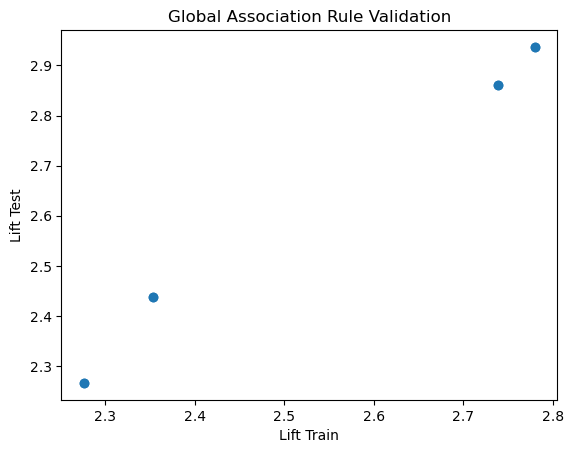

In [22]:
plt.scatter(
    evaluation['lift_train'],
    evaluation['lift_test'],
)

plt.xlabel('Lift Train')
plt.ylabel('Lift Test')
plt.title('Global Association Rule Validation')
plt.show()

In [23]:
print("Train rules:", len(rules_train))
print("Test rules:", len(rules_test))
print("Common rules:", len(evaluation))

Train rules: 18
Test rules: 8
Common rules: 8


In [24]:
evaluation[['support_train', 'support_test', 
            'confidence_train', 'confidence_test', 
            'lift_train', 'lift_test']].describe().round(3)

,support_train,support_test,confidence_train,confidence_test,lift_train,lift_test
count,8.000,8.000,8.000,8.000,8.000,8.000
mean,0.024,0.024,0.249,0.254,2.537,2.626
std,0.001,0.002,0.055,0.059,0.240,0.301
min,0.022,0.021,0.203,0.212,2.276,2.266
25%,0.023,0.022,0.214,0.217,2.334,2.395
50%,0.024,0.024,0.228,0.224,2.546,2.649
75%,0.025,0.026,0.260,0.265,2.749,2.880
max,0.025,0.026,0.338,0.354,2.780,2.937


We can calculate the % absolute difference between the values to have a metric on how well our train and test scenarios approximate:

In [25]:
mean_lift_perc_difference = (np.abs(evaluation['lift_train'] - evaluation['lift_test'])/evaluation['lift_train']).mean()

print(f"Mean absolute percentage difference in lift: {mean_lift_perc_difference:.2%}")

Mean absolute percentage difference in lift: 3.54%


The common rules between train and test show very similar lift values, with a mean absolute percentage difference of 3.54%. This suggests that the strongest global associations are stable and not only specific to the training subset.

Although only 8 rules are common between train and test under the selected thresholds, these rules show consistent lift values, which supports the robustness of the global association patterns.

## **5. Cluster-Specific Association Rules**

After validating the global association rules, we now generate association rules separately for each customer segment. This allows us to identify product associations that are more specific to each cluster and therefore more useful for targeted promotion strategies.

For each cluster, we filter the training baskets, encode the product lists, extract frequent itemsets with Apriori, and generate association rules using confidence and lift thresholds.

### **5.1. Interpretation Note: Frequent Itemsets vs Association Rules**

Frequent itemsets show which products appear often within each cluster, while association rules ranked by lift show which product combinations are unusually strong. Therefore, campaign suggestions are based mainly on high-lift rules, not only on the most frequent individual products.

In [27]:
train_baskets_df.head()

,invoice_id,list_of_goods,customer_id,basket_size,cluster_kmeans,cluster_name
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11,3,Senior Karens
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12,4,Promotion Lovers
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7,3,Senior Karens
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4,7,Large Families
5,9814176,"[cottage cheese, samsung galaxy 10, strawberries, megaman zero, asparagus, bacon, metroid prime, oatmeal, sparkling water, flax seed, pet food, phone charger, tomato sauce, green grapes, red wine, whole wheat pasta, black beer]",36382,17,2,Clean & Green


### **5.2. Association Rules tailored to each customer**

#### **Cluster 0 - Regular Customers**

In [28]:
cluster_0 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 0]
transactions_items_train_0, support_itemsets_train_0, rules_train_0 = generate_rules(cluster_0, min_support=0.02, min_confidence=0.15)


display(support_itemsets_train_0.sort_values("support", ascending=False).head(10))
display(rules_train_0.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
0,0.189061,(airpods)
12,0.115266,(bluetooth headphones)
47,0.113412,(energy drink)
3,0.107787,(asparagus)
46,0.086836,(energy bar)
120,0.086527,(protein bar)
80,0.083931,(laptop)
78,0.081459,(iphone 10)
15,0.080161,(brownies)
127,0.077132,(ring light)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(energy drink),(bluetooth headphones),0.113412,0.115266,0.029728,0.262125,2.274095,1.0,0.016656,1.199031,0.631933,0.149425,0.165993,0.260017
4,(bluetooth headphones),(energy drink),0.115266,0.113412,0.029728,0.257909,2.274095,1.0,0.016656,1.194716,0.633258,0.149425,0.162981,0.260017
0,(energy drink),(airpods),0.113412,0.189061,0.046044,0.405995,2.147431,1.0,0.024603,1.365205,0.602678,0.179561,0.267509,0.324769
1,(airpods),(energy drink),0.189061,0.113412,0.046044,0.243544,2.147431,1.0,0.024603,1.172028,0.658899,0.179561,0.146778,0.324769
2,(bluetooth headphones),(airpods),0.115266,0.189061,0.045735,0.396783,2.098708,1.0,0.023943,1.344357,0.591721,0.176864,0.256150,0.319346
3,(airpods),(bluetooth headphones),0.189061,0.115266,0.045735,0.241909,2.098708,1.0,0.023943,1.167056,0.645568,0.176864,0.143143,0.319346
10,(iphone 10),(airpods),0.081459,0.189061,0.028554,0.350531,1.854068,1.0,0.013153,1.248619,0.501497,0.118008,0.199115,0.250780
11,(airpods),(iphone 10),0.189061,0.081459,0.028554,0.151030,1.854068,1.0,0.013153,1.081948,0.568039,0.118008,0.075741,0.250780
13,(pancakes),(airpods),0.073486,0.189061,0.025525,0.347351,1.837246,1.0,0.011632,1.242535,0.491851,0.107692,0.195194,0.241181
6,(protein bar),(airpods),0.086527,0.189061,0.029543,0.341429,1.805922,1.0,0.013184,1.231361,0.488538,0.120070,0.187891,0.248844


**For each cluster, we also calculate product relevance by comparing the product support inside the cluster with its global support. A support ratio above 1 means that the product is more frequent in that cluster than in the overall training basket dataset. This helps identify products that are especially characteristic of each segment, which allow more complete targeted promotions.**

#### **Cluster 1 - Gamers**

In [30]:
cluster_1 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 1]
transactions_items_train_1, support_itemsets_train_1, rules_train_1 = generate_rules(cluster_1, min_support=0.02, min_confidence=0.15)


display(support_itemsets_train_1.sort_values("support", ascending=False).head(10))
display(rules_train_1.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
150,0.350381,(toothpaste)
135,0.347641,(shower gel)
41,0.345510,(deodorant)
134,0.343836,(shampoo)
149,0.340944,(tooth brush)
46,0.238204,(energy bar)
120,0.233333,(protein bar)
2,0.215677,(antioxydant juice)
13,0.214612,(body spray)
124,0.211416,(razor)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
746,(bluetooth headphones),(airpods),0.064992,0.119026,0.030594,0.470726,3.954821,1.0,0.022858,1.664495,0.799078,0.199405,0.399217,0.363880
747,(airpods),(bluetooth headphones),0.119026,0.064992,0.030594,0.257033,3.954821,1.0,0.022858,1.258478,0.848089,0.199405,0.205390,0.363880
1471,(iphone 10),(airpods),0.051142,0.119026,0.021613,0.422619,3.550649,1.0,0.015526,1.525811,0.757080,0.145492,0.344611,0.302102
1472,(airpods),(iphone 10),0.119026,0.051142,0.021613,0.181586,3.550649,1.0,0.015526,1.159386,0.815417,0.145492,0.137475,0.302102
634,(energy drink),(airpods),0.080822,0.119026,0.033333,0.412429,3.465040,1.0,0.023713,1.499350,0.773956,0.200183,0.333044,0.346240
635,(airpods),(energy drink),0.119026,0.080822,0.033333,0.280051,3.465040,1.0,0.023713,1.276727,0.807519,0.200183,0.216747,0.346240
1072,"(deodorant, protein bar)","(shampoo, tooth brush)",0.093912,0.150228,0.025419,0.270665,1.801688,1.0,0.011310,1.165131,0.491083,0.116214,0.141728,0.219932
1069,"(shampoo, tooth brush)","(deodorant, protein bar)",0.150228,0.093912,0.025419,0.169200,1.801688,1.0,0.011310,1.090621,0.523629,0.116214,0.083091,0.219932
1050,"(shampoo, toilet paper)","(deodorant, toothpaste)",0.093151,0.156925,0.025571,0.274510,1.749301,1.0,0.010953,1.162076,0.472342,0.113898,0.139471,0.218729
1051,"(deodorant, toothpaste)","(shampoo, toilet paper)",0.156925,0.093151,0.025571,0.162949,1.749301,1.0,0.010953,1.083385,0.508073,0.113898,0.076967,0.218729


#### **Cluster 2 - Clean & Green**

In [32]:
cluster_2 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 2]
transactions_items_train_2, support_itemsets_train_2, rules_train_2 = generate_rules(cluster_2, min_support=0.02, min_confidence=0.15)


display(support_itemsets_train_2.sort_values("support", ascending=False).head(10))
display( rules_train_2.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
0,0.106573,(airpods)
120,0.097118,(protein bar)
3,0.096664,(asparagus)
54,0.090613,(french fries)
125,0.086075,(red wine)
80,0.083050,(laptop)
131,0.082218,(samsung galaxy 10)
137,0.079570,(shrimp)
104,0.079268,(oil)
78,0.077982,(iphone 10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


No strong association rules were found for this cluster using the selected support and confidence thresholds. Therefore, the promotion suggestion for this segment is based on the most frequent itemsets rather than association rules.

#### **Cluster 3 - Senior Karens**

In [34]:
cluster_3 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 3]
transactions_items_train_3, support_itemsets_train_3, rules_train_3 = generate_rules(cluster_3, min_support=0.02, min_confidence=0.15)


display(support_itemsets_train_3.sort_values("support", ascending=False).head(10))
display(rules_train_3.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
3,0.137206,(asparagus)
56,0.111146,(fresh bread)
0,0.101413,(airpods)
74,0.095133,(honey)
18,0.092936,(butter)
26,0.092308,(cereals)
45,0.086342,(eggs)
111,0.084144,(phone car charger)
145,0.083203,(tea)
54,0.081947,(french fries)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(eggs),(cereals),0.086342,0.092308,0.021036,0.243636,2.639394,1.0,0.013066,1.200074,0.679823,0.133466,0.166718,0.235764
0,(cereals),(eggs),0.092308,0.086342,0.021036,0.227891,2.639394,1.0,0.013066,1.183328,0.684290,0.133466,0.154926,0.235764
3,(cereals),(fresh bread),0.092308,0.111146,0.020408,0.221088,1.989171,1.0,0.010149,1.141149,0.547849,0.111492,0.123690,0.202352
2,(fresh bread),(cereals),0.111146,0.092308,0.020408,0.183616,1.989171,1.0,0.010149,1.111845,0.559460,0.111492,0.100594,0.202352


#### **Cluster 4 - Promotion Lovers**

In [36]:
cluster_4 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 4]
transactions_items_train_4, support_itemsets_train_4, rules_train_4 = generate_rules(cluster_4, min_support=0.02, min_confidence=0.15)


display(support_itemsets_train_4.sort_values("support", ascending=False).head(10))
display(rules_train_4.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
0,0.201721,(airpods)
12,0.112261,(bluetooth headphones)
47,0.108140,(energy drink)
3,0.107041,(asparagus)
80,0.105943,(laptop)
15,0.095138,(brownies)
46,0.092391,(energy bar)
120,0.090010,(protein bar)
78,0.088453,(iphone 10)
89,0.081403,(megaman zero 3)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
23,"(energy drink, airpods)",(bluetooth headphones),0.052651,0.112261,0.022159,0.420870,3.749035,1.0,0.016249,1.532883,0.774017,0.155228,0.347635,0.309130
24,(bluetooth headphones),"(energy drink, airpods)",0.112261,0.052651,0.022159,0.197390,3.749035,1.0,0.016249,1.180335,0.825991,0.155228,0.152783,0.309130
22,"(bluetooth headphones, airpods)",(energy drink),0.054940,0.108140,0.022159,0.403333,3.729723,1.0,0.016218,1.494737,0.774431,0.157245,0.330986,0.304122
25,(energy drink),"(bluetooth headphones, airpods)",0.108140,0.054940,0.022159,0.204911,3.729723,1.0,0.016218,1.188622,0.820626,0.157245,0.158689,0.304122
21,"(bluetooth headphones, energy drink)",(airpods),0.034612,0.201721,0.022159,0.640212,3.173741,1.0,0.015177,2.218745,0.709471,0.103463,0.549295,0.375031
5,(energy drink),(bluetooth headphones),0.108140,0.112261,0.034612,0.320068,2.851109,1.0,0.022472,1.305629,0.727984,0.186299,0.234086,0.314194
4,(bluetooth headphones),(energy drink),0.112261,0.108140,0.034612,0.308320,2.851109,1.0,0.022472,1.289410,0.731363,0.186299,0.224452,0.314194
1,(airpods),(bluetooth headphones),0.201721,0.112261,0.054940,0.272356,2.426100,1.0,0.032295,1.220018,0.736354,0.212089,0.180340,0.380876
0,(bluetooth headphones),(airpods),0.112261,0.201721,0.054940,0.489396,2.426100,1.0,0.032295,1.563402,0.662149,0.212089,0.360369,0.380876
2,(energy drink),(airpods),0.108140,0.201721,0.052651,0.486876,2.413603,1.0,0.030837,1.555721,0.656697,0.204699,0.357211,0.373942


#### **Cluster 5 - Low-Value Occasional Customers**

In [38]:
cluster_5 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 5]
transactions_items_train_5, support_itemsets_train_5, rules_train_5 = generate_rules(cluster_5, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_5.sort_values("support", ascending=False).head(10))
display(rules_train_5.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
43,0.283900,(dog food)
5,0.276578,(babies food)
101,0.273427,(napkins)
36,0.267309,(cooking oil)
56,0.160719,(fresh bread)
146,0.159236,(toilet paper)
26,0.158124,(cereals)
110,0.157753,(pet food)
23,0.157290,(cat food)
28,0.156919,(chicken)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
173,"(chicken, napkins)",(dog food),0.050978,0.283900,0.021596,0.423636,1.492201,1.0,0.007123,1.242444,0.347567,0.068935,0.195135,0.249853
172,"(chicken, dog food)",(napkins),0.054315,0.273427,0.021596,0.397611,1.454178,1.0,0.006745,1.206153,0.330264,0.070542,0.170918,0.238297
200,"(chicken, napkins)",(babies food),0.050978,0.276578,0.020298,0.398182,1.439673,1.0,0.006199,1.202061,0.321803,0.066063,0.168095,0.235787
176,"(chicken, dog food)",(babies food),0.054315,0.276578,0.021503,0.395904,1.431439,1.0,0.006481,1.197529,0.318713,0.069503,0.164947,0.236826
175,"(chicken, babies food)",(dog food),0.052924,0.283900,0.021503,0.406305,1.431153,1.0,0.006478,1.206174,0.318098,0.068195,0.170932,0.241024
178,"(fresh bread, dog food)",(napkins),0.055334,0.273427,0.021503,0.388610,1.421258,1.0,0.006374,1.188395,0.313759,0.069985,0.158529,0.233627
186,"(toilet paper, dog food)",(napkins),0.054500,0.273427,0.021040,0.386054,1.411912,1.0,0.006138,1.183449,0.308557,0.068559,0.155012,0.231502
187,"(toilet paper, napkins)",(dog food),0.052554,0.283900,0.021040,0.400353,1.410188,1.0,0.006120,1.194202,0.307009,0.066706,0.162620,0.237232
205,"(babies food, pet food)",(dog food),0.050514,0.283900,0.020206,0.400000,1.408945,1.0,0.005865,1.193500,0.305691,0.064307,0.162128,0.235586
199,"(chicken, babies food)",(napkins),0.052924,0.273427,0.020298,0.383538,1.402708,1.0,0.005828,1.178618,0.303136,0.066323,0.151548,0.228887


#### **Cluster 6 - High-Value Customers**

In [40]:
cluster_6 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 6]
transactions_items_train_6, support_itemsets_train_6, rules_train_6 = generate_rules(cluster_6, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_6.sort_values("support", ascending=False).head(10))
display(rules_train_6.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
3,0.147987,(asparagus)
0,0.127715,(airpods)
74,0.098755,(honey)
56,0.098465,(fresh bread)
46,0.092383,(energy bar)
145,0.089922,(tea)
26,0.089343,(cereals)
103,0.083695,(oatmeal)
149,0.082827,(tomatoes)
8,0.082827,(beer)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(cereals),(butter),0.089343,0.080510,0.020272,0.226904,2.818348,1.0,0.013079,1.189362,0.708480,0.135528,0.159213,0.239351
0,(butter),(cereals),0.080510,0.089343,0.020272,0.251799,2.818348,1.0,0.013079,1.217129,0.701674,0.135528,0.178394,0.239351


#### **Cluster 7 - Large Families**

In [42]:
cluster_7 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 7]
transactions_items_train_7, support_itemsets_train_7, rules_train_7 = generate_rules(cluster_7, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_7.sort_values("support", ascending=False).head(10))
display(rules_train_7.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
24,0.376185,(cereals)
51,0.373712,(fresh bread)
16,0.371515,(butter)
43,0.363961,(eggs)
6,0.226068,(bacon)
89,0.215767,(oatmeal)
67,0.213432,(honey)
119,0.213158,(tea)
81,0.202719,(milk)
9,0.155610,(black tea)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
501,(green tea),"(cereals, eggs)",0.113721,0.154374,0.022936,0.201691,1.306504,1.0,0.005381,1.059271,0.264701,0.093557,0.055954,0.175134
500,"(eggs, green tea)",(cereals),0.047384,0.376185,0.022936,0.484058,1.286757,1.0,0.005111,1.209080,0.233937,0.057251,0.172925,0.272515
329,(black tea),(salt),0.155610,0.147507,0.029529,0.189762,1.286457,1.0,0.006575,1.052151,0.263707,0.107932,0.049566,0.194974
330,(salt),(black tea),0.147507,0.155610,0.029529,0.200186,1.286457,1.0,0.006575,1.055733,0.261200,0.107932,0.052790,0.194974
488,"(cereals, milk)",(oatmeal),0.085016,0.215767,0.023486,0.276252,1.280325,1.0,0.005142,1.083572,0.239292,0.084695,0.077126,0.192550
486,"(oatmeal, cereals)",(milk),0.090647,0.202719,0.023486,0.259091,1.278076,1.0,0.005110,1.076084,0.239263,0.087023,0.070705,0.187472
154,"(butter, honey)",(eggs),0.086527,0.363961,0.040104,0.463492,1.273466,1.0,0.008612,1.185516,0.235083,0.097724,0.156486,0.286840
476,"(oatmeal, fresh bread)",(honey),0.088587,0.213432,0.024035,0.271318,1.271213,1.0,0.005128,1.079439,0.234087,0.086462,0.073593,0.191965
487,"(oatmeal, milk)",(cereals),0.049169,0.376185,0.023486,0.477654,1.269732,1.0,0.004989,1.194256,0.223417,0.058442,0.162659,0.270043
504,"(oatmeal, fresh bread)",(milk),0.088587,0.202719,0.022799,0.257364,1.269559,1.0,0.004841,1.073582,0.232963,0.084910,0.068539,0.184915


#### **Cluster 8 - Young Karens**

In [44]:
cluster_8 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 8]
transactions_items_train_8, support_itemsets_train_8, rules_train_8 = generate_rules(cluster_8, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_8.sort_values("support", ascending=False).head(10))
display(rules_train_8.sort_values(["lift", "confidence"], ascending=False).head(10))

,support,itemsets
3,0.560701,(asparagus)
109,0.358782,(spinach)
116,0.355444,(tomatoes)
96,0.353567,(salad)
4,0.347935,(avocado)
21,0.346058,(carrots)
164,0.235294,"(salad, asparagus)"
166,0.232791,"(asparagus, spinach)"
148,0.223196,"(asparagus, avocado)"
168,0.219858,"(tomatoes, asparagus)"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2311,"(asparagus, frozen vegetables)","(tomatoes, salad)",0.091573,0.143513,0.021277,0.232346,1.618994,1.0,0.008135,1.115721,0.420873,0.099512,0.103718,0.190301
1274,"(strawberries, asparagus)","(salad, avocado)",0.125156,0.144556,0.028995,0.231667,1.602612,1.0,0.010902,1.113377,0.429812,0.120451,0.101831,0.216122
1273,"(salad, avocado)","(strawberries, asparagus)",0.144556,0.125156,0.028995,0.200577,1.602612,1.0,0.010902,1.094344,0.439559,0.120451,0.086211,0.216122
2365,"(carrots, tomatoes, asparagus)","(salad, spinach)",0.087818,0.149145,0.020859,0.237530,1.592612,1.0,0.007762,1.115919,0.407924,0.096525,0.103878,0.188695
1163,"(mineral water, spinach)","(salad, asparagus)",0.083646,0.235294,0.031289,0.374065,1.589776,1.0,0.011608,1.221701,0.404844,0.108774,0.181469,0.253522
1161,"(salad, spinach)","(mineral water, asparagus)",0.149145,0.132666,0.031289,0.209790,1.581343,1.0,0.011503,1.097600,0.432067,0.124896,0.088921,0.222820
1162,"(mineral water, asparagus)","(salad, spinach)",0.132666,0.149145,0.031289,0.235849,1.581343,1.0,0.011503,1.113465,0.423858,0.124896,0.101903,0.222820
2335,"(asparagus, corn)","(tomatoes, spinach)",0.090321,0.148102,0.021068,0.233256,1.574973,1.0,0.007691,1.111060,0.401316,0.096929,0.099959,0.187755
1160,"(mineral water, salad)","(asparagus, spinach)",0.085524,0.232791,0.031289,0.365854,1.571597,1.0,0.011380,1.209830,0.397719,0.109012,0.173437,0.250131
2450,"(asparagus, corn)","(avocado, spinach)",0.090321,0.144973,0.020442,0.226328,1.561174,1.0,0.007348,1.105154,0.395147,0.095146,0.095149,0.183668


## **6. Final Campaign Suggestions**

The cluster-specific association rules provide product-level evidence for designing targeted campaigns. Some clusters show strong rule-based patterns, while others are better supported by frequent itemsets. Overall, the rules confirm that different customer segments have distinct basket compositions, allowing promotions to be adapted to each cluster's behavior.